# Proyecto 2 — Clasificación de Señales Eco-Acústicas (CS3061 · ML · UTEC)

Pipeline integral de Machine Learning para identificación autónoma de especies a partir de
características Mel (MFCC, $X \in \mathbb{R}^{64}$).

**Estructura del notebook (alineada a la rúbrica):**
1. Configuración, ingesta y EDA (espacio vectorial)
2. Reducción de dimensionalidad: PCA vs UMAP vs t-SNE
3. Clustering: DBSCAN vs Gaussian Mixture (paradigmas distintos)
4. Clasificación: MLP (PyTorch) vs XGBoost — F1 macro + matrices de confusión
5. Mitigación de riesgos: umbrales probabilísticos (3 zonas) + trade-offs

> Las clases son **5** (`species_id` = 10, 12, 17, 18, 23) y están **desbalanceadas**, por eso
> la métrica rectora es **F1-Score macro**, no accuracy.

## 0. Configuración del entorno

In [1]:
# %pip install scikit-learn umap-learn xgboost torch matplotlib seaborn -q

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Penalizacion de la rubrica: fuente de ejes/leyendas >= 14 ---
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 110,
})
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerias base cargadas.')

Librerias base cargadas.


## 1. Ingesta de datos y EDA — Definición del espacio vectorial

Cada observación es un vector $x \in \mathbb{R}^{64}$ de coeficientes Mel (`mel_0`…`mel_63`).
Las columnas `recording_id`, `songtype_id` e `is_tp` son **metadatos** y no se usan como
predictoras. El objetivo es `species_id`.

In [3]:
TRAIN_PATH = 'eco_acoustic_train.csv'   # ajusta la ruta si es necesario
TEST_PATH  = 'eco_acoustic_test.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

MEL_COLS = [f'mel_{i}' for i in range(64)]
META_COLS = ['recording_id', 'songtype_id', 'is_tp']
TARGET = 'species_id'

print('Train:', df_train.shape, '| Test:', df_test.shape)
print('Nulos en mel (train):', df_train[MEL_COLS].isna().sum().sum())
df_train.head(3)

Train: (1906, 68) | Test: (477, 68)
Nulos en mel (train): 0


,recording_id,species_id,songtype_id,is_tp,mel_0,mel_1,mel_2,mel_3,mel_4,mel_5,...,mel_54,mel_55,mel_56,mel_57,mel_58,mel_59,mel_60,mel_61,mel_62,mel_63
0,8028f97c2,12,1,0,0.761312,0.560260,0.658140,0.914652,1.028028,0.927718,...,0.640066,0.709767,0.832127,0.978034,1.170270,1.616394,1.485580,1.532548,1.678811,1.746231
1,7e60a570a,23,1,0,-0.165556,-0.423311,-0.388817,-0.358183,-0.538184,-0.606904,...,0.513191,0.609958,0.752890,1.025070,1.124224,1.343504,1.402325,1.462375,1.535544,1.611380
2,b441cf212,23,4,1,-0.099009,-0.156101,-0.296446,-0.522058,-0.825982,-0.705668,...,-0.006846,0.059616,0.120859,0.281452,0.403537,0.552586,0.573619,0.656946,0.792357,1.002647


In [4]:
# Catalogo taxonomico (de la documentacion del dataset)
SPECIES_INFO = {
    10: ('Leptodactylus discodactylus', 'Anfibio'),
    12: ('Osteocephalus taurinus',      'Anfibio'),
    17: ('Chiroxiphia lineata',         'Ave'),
    18: ('Saltator grossus',            'Ave'),
    23: ('Pheucticus chrysopeplus',     'Ave'),
}

counts = df_train[TARGET].value_counts().sort_index()
dist = pd.DataFrame({
    'n_train': counts,
    'pct_train': (counts / counts.sum() * 100).round(1),
    'especie': [SPECIES_INFO[i][0] for i in counts.index],
    'fauna':   [SPECIES_INFO[i][1] for i in counts.index],
})
print(dist)
print('\nRatio de desbalance (max/min): %.2f' % (counts.max() / counts.min()))

            n_train  pct_train                      especie    fauna
species_id                                                          
10              277       14.5  Leptodactylus discodactylus  Anfibio
12              277       14.5       Osteocephalus taurinus  Anfibio
17              521       27.3          Chiroxiphia lineata      Ave
18              278       14.6             Saltator grossus      Ave
23              553       29.0      Pheucticus chrysopeplus      Ave

Ratio de desbalance (max/min): 2.00


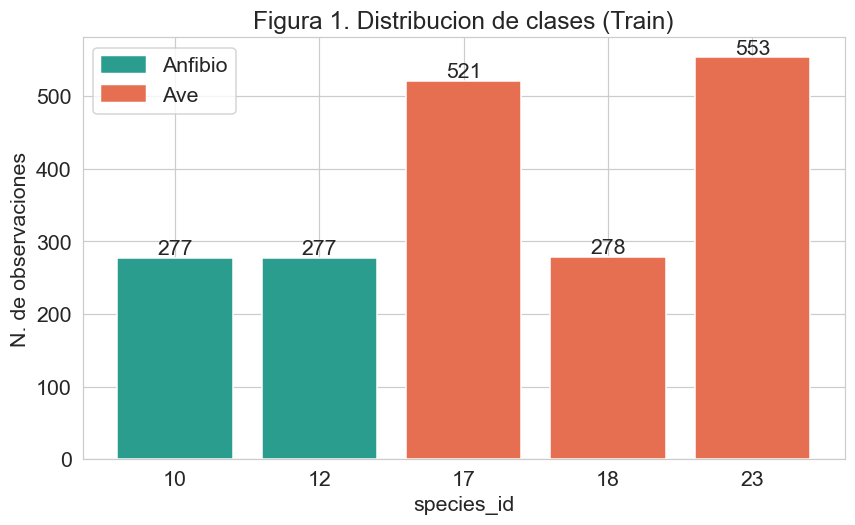

In [5]:
# Figura 1: distribucion de clases (evidencia el desbalance)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2a9d8f' if SPECIES_INFO[i][1]=='Anfibio' else '#e76f51' for i in counts.index]
ax.bar([str(i) for i in counts.index], counts.values, color=colors)
ax.set_xlabel('species_id')
ax.set_ylabel('N. de observaciones')
ax.set_title('Figura 1. Distribucion de clases (Train)')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=14)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2a9d8f', label='Anfibio'),
                   Patch(color='#e76f51', label='Ave')])
plt.tight_layout(); plt.show()

In [6]:
# Matrices X / y y estandarizacion (fit SOLO en train para evitar fuga de datos)
from sklearn.preprocessing import StandardScaler

X_train = df_train[MEL_COLS].values.astype(np.float32)
y_train = df_train[TARGET].values
X_test  = df_test[MEL_COLS].values.astype(np.float32)
y_test  = df_test[TARGET].values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print('X_train_s:', X_train_s.shape, '| X_test_s:', X_test_s.shape)
print('Media ~0, std ~1 ->', round(X_train_s.mean(),4), round(X_train_s.std(),4))

X_train_s: (1906, 64) | X_test_s: (477, 64)
Media ~0, std ~1 -> -0.0 1.0


## 2. Reducción de dimensionalidad: PCA vs UMAP vs t-SNE

Se contrasta un método **lineal** (PCA, preserva varianza global) frente a dos métodos de
**variedades múltiples** (t-SNE y UMAP, preservan estructura local). Se reportan **tiempos de
ejecución** y capacidad de retención de estructura.

Componentes para 90% var: 7 | para 95% var: 11


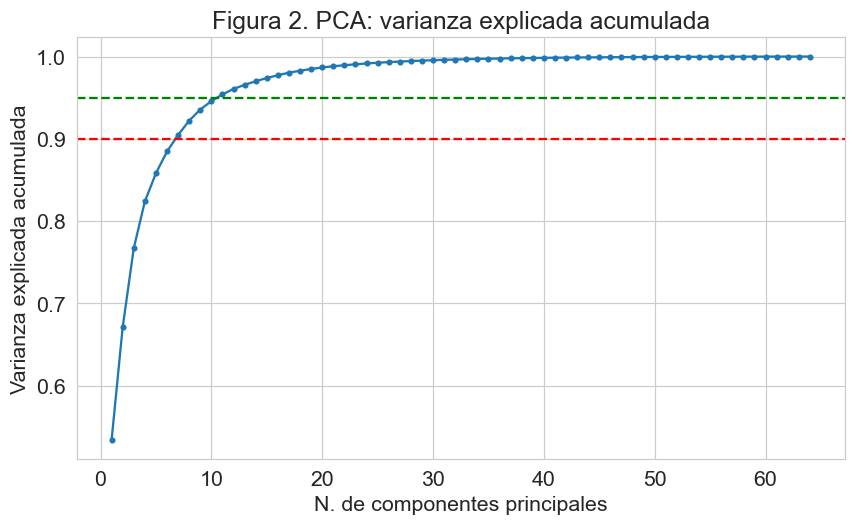

In [7]:
from sklearn.decomposition import PCA

# --- PCA: varianza explicada acumulada ---
pca_full = PCA(n_components=64, random_state=RANDOM_STATE).fit(X_train_s)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90) + 1)
n_95 = int(np.argmax(cumvar >= 0.95) + 1)
print(f'Componentes para 90% var: {n_90} | para 95% var: {n_95}')

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(1,65), cumvar, marker='o', ms=3)
ax.axhline(0.90, color='r', ls='--'); ax.axhline(0.95, color='g', ls='--')
ax.set_xlabel('N. de componentes principales')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title('Figura 2. PCA: varianza explicada acumulada')
plt.tight_layout(); plt.show()

In [8]:
# Proyeccion 2D con los tres metodos, midiendo tiempos
from sklearn.manifold import TSNE
import umap

timings = {}

t0 = time.perf_counter()
emb_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_train_s)
timings['PCA'] = time.perf_counter() - t0

t0 = time.perf_counter()
emb_tsne = TSNE(n_components=2, perplexity=30, init='pca',
                random_state=RANDOM_STATE).fit_transform(X_train_s)
timings['t-SNE'] = time.perf_counter() - t0

t0 = time.perf_counter()
emb_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                     random_state=RANDOM_STATE).fit_transform(X_train_s)
timings['UMAP'] = time.perf_counter() - t0

print('Tiempos de ejecucion (s):')
for k,v in timings.items():
    print(f'  {k:8s}: {v:.2f}')

C:\Users\illes\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tiempos de ejecucion (s):
  PCA     : 0.01
  t-SNE   : 15.43
  UMAP    : 27.28


C:\Users\illes\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


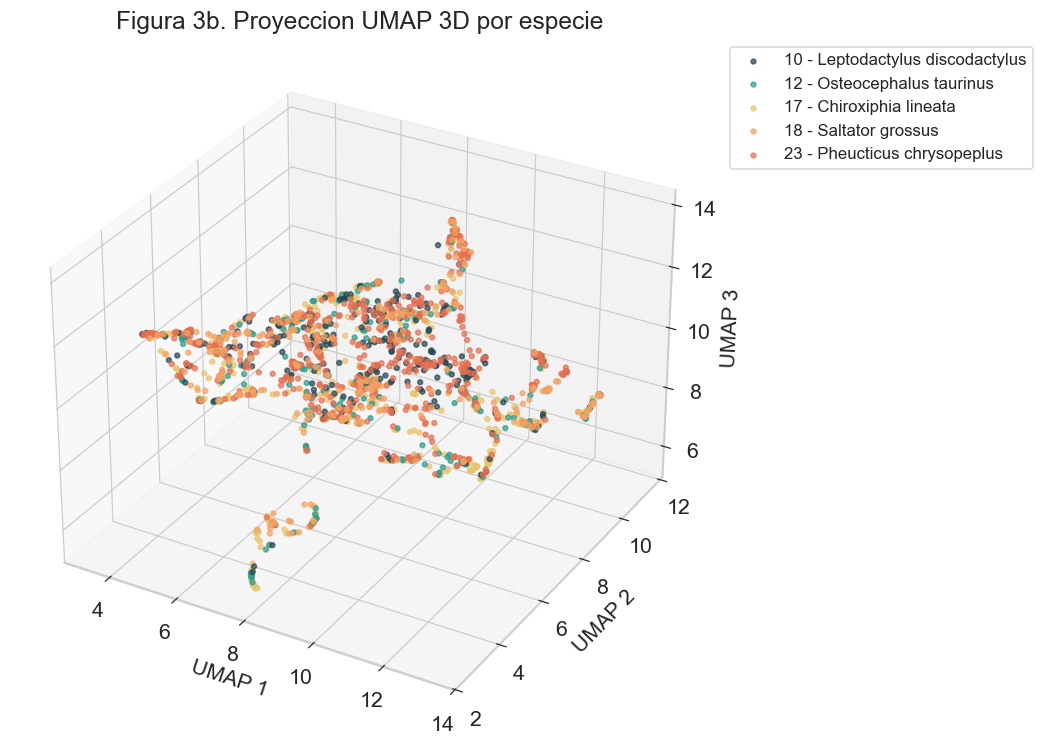

In [9]:
# Proyeccion UMAP 3D (complementa los scatter 2D; la rubrica admite 2D o 3D)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registra la proyeccion 3d)

# Paleta local (independiente del orden de ejecucion de otras secciones)
palette = {10:'#264653', 12:'#2a9d8f', 17:'#e9c46a', 18:'#f4a261', 23:'#e76f51'}

emb_umap3 = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                      random_state=RANDOM_STATE).fit_transform(X_train_s)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
for k in palette:
    m = y_train == k
    ax.scatter(emb_umap3[m,0], emb_umap3[m,1], emb_umap3[m,2],
               c=palette[k], s=10, alpha=0.7, label=f'{k} - {SPECIES_INFO[k][0]}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2'); ax.set_zlabel('UMAP 3')
ax.set_title('Figura 3b. Proyeccion UMAP 3D por especie')
ax.legend(loc='upper left', fontsize=11, bbox_to_anchor=(1.02, 1.0))
plt.tight_layout(); plt.show()

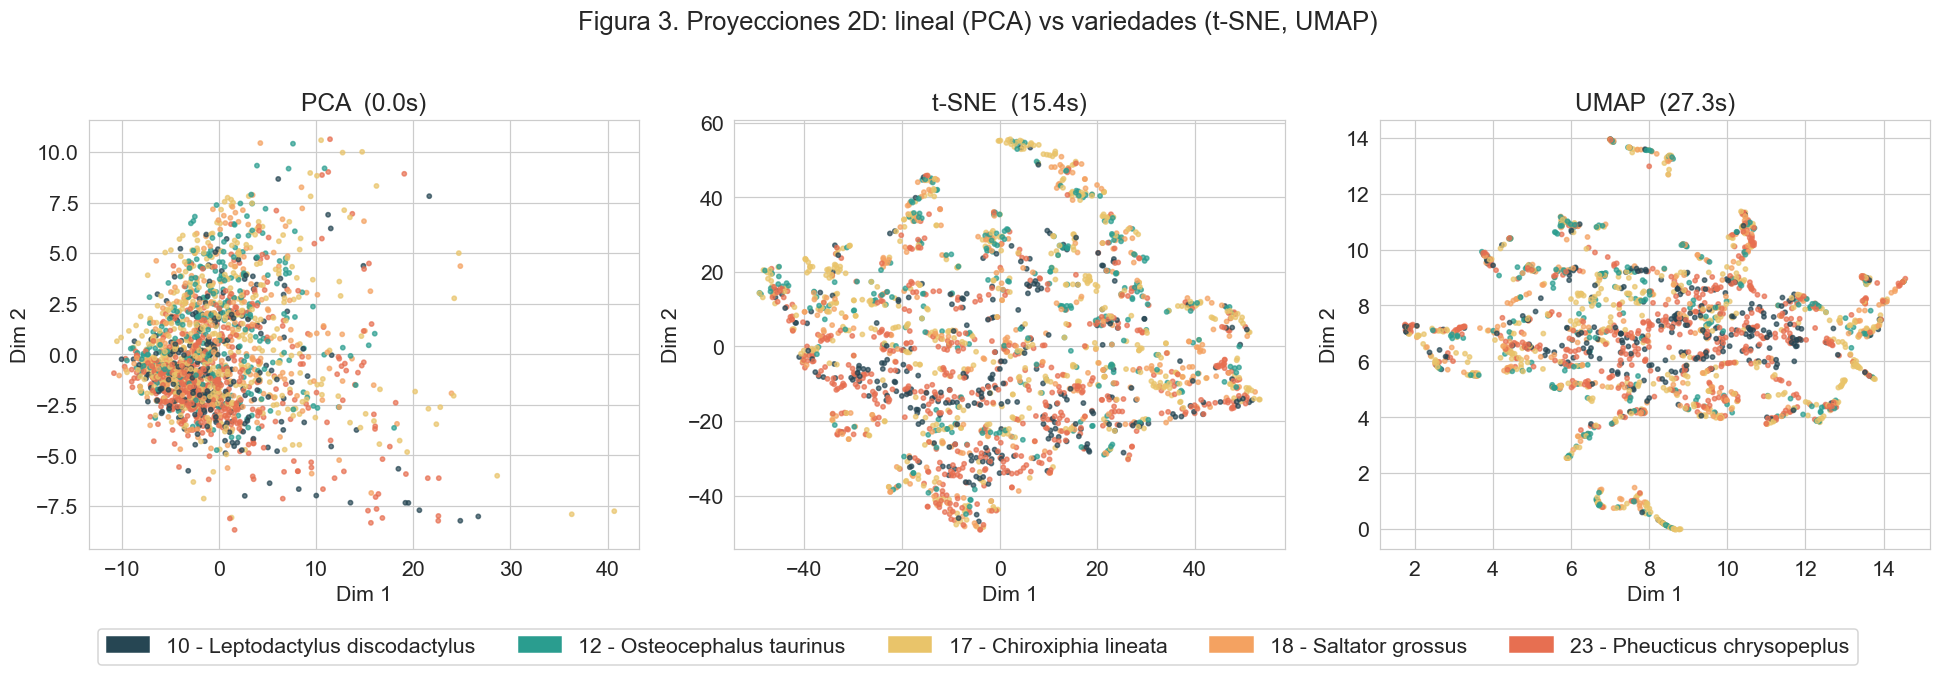

In [10]:
# Figura 3: comparacion visual de las tres proyecciones 2D
palette = {10:'#264653',12:'#2a9d8f',17:'#e9c46a',18:'#f4a261',23:'#e76f51'}
cols = [palette[c] for c in y_train]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, emb) in zip(axes, [('PCA',emb_pca),('t-SNE',emb_tsne),('UMAP',emb_umap)]):
    ax.scatter(emb[:,0], emb[:,1], c=cols, s=8, alpha=0.7)
    ax.set_title(f'{name}  ({timings[name]:.1f}s)')
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
handles = [Patch(color=palette[k], label=f'{k} - {SPECIES_INFO[k][0]}') for k in palette]
fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5,-0.08))
fig.suptitle('Figura 3. Proyecciones 2D: lineal (PCA) vs variedades (t-SNE, UMAP)', y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# Metrica cuantitativa de retencion de estructura: trustworthiness (preservacion local)
from sklearn.manifold import trustworthiness

tw = {name: trustworthiness(X_train_s, emb, n_neighbors=10)
      for name, emb in [('PCA',emb_pca),('t-SNE',emb_tsne),('UMAP',emb_umap)]}

resumen_dr = pd.DataFrame({
    'tiempo_s': {k: round(v,2) for k,v in timings.items()},
    'trustworthiness': {k: round(v,3) for k,v in tw.items()},
    'tipo': {'PCA':'lineal (var. global)', 't-SNE':'variedad (local)', 'UMAP':'variedad (local)'}
})
print(resumen_dr)
print('\nVarianza retenida por PCA-2D: %.1f%%' % (pca_full.explained_variance_ratio_[:2].sum()*100))

       tiempo_s  trustworthiness                  tipo
PCA        0.01            0.867  lineal (var. global)
t-SNE     15.43            0.987      variedad (local)
UMAP      27.28            0.979      variedad (local)

Varianza retenida por PCA-2D: 67.1%


**Lectura.** PCA es el más rápido y da una referencia de varianza global, pero al ser lineal
solapa clases. t-SNE/UMAP separan mejor los grupos (mayor *trustworthiness*) a costa de más
cómputo; UMAP suele preservar mejor la estructura global que t-SNE y escala mejor.

## 3. Clustering: DBSCAN vs Gaussian Mixture (paradigmas distintos)

Se comparan dos paradigmas: densidad (DBSCAN) frente a probabilístico (GMM). El número
de grupos se justifica con el **Coeficiente de Silhouette** (y métricas auxiliares). Se trabaja
sobre un espacio PCA que retiene ~95% de varianza para reducir ruido y costo.

In [12]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

X_pca = PCA(n_components=n_95, random_state=RANDOM_STATE).fit_transform(X_train_s)
print('Espacio de clustering:', X_pca.shape)

Espacio de clustering: (1906, 11)


In [13]:
# --- GMM: seleccion de k por Silhouette + BIC ---
ks = range(2, 9)
rows = []
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=3).fit(X_pca)
    labels = gmm.predict(X_pca)
    rows.append({'k': k,
                 'silhouette': silhouette_score(X_pca, labels),
                 'BIC': gmm.bic(X_pca),
                 'ARI_vs_especie': adjusted_rand_score(y_train, labels)})
gmm_sel = pd.DataFrame(rows)
print(gmm_sel.round(3))
best_k = int(gmm_sel.loc[gmm_sel.silhouette.idxmax(), 'k'])
print('\nk optimo por Silhouette:', best_k)

   k  silhouette        BIC  ARI_vs_especie
0  2       0.184  72342.678           0.026
1  3       0.110  69716.231           0.036
2  4       0.076  68666.956           0.036
3  5      -0.010  68025.646           0.026
4  6      -0.036  67473.960           0.026
5  7      -0.017  66477.873           0.035
6  8      -0.040  65890.797           0.036

k optimo por Silhouette: 2


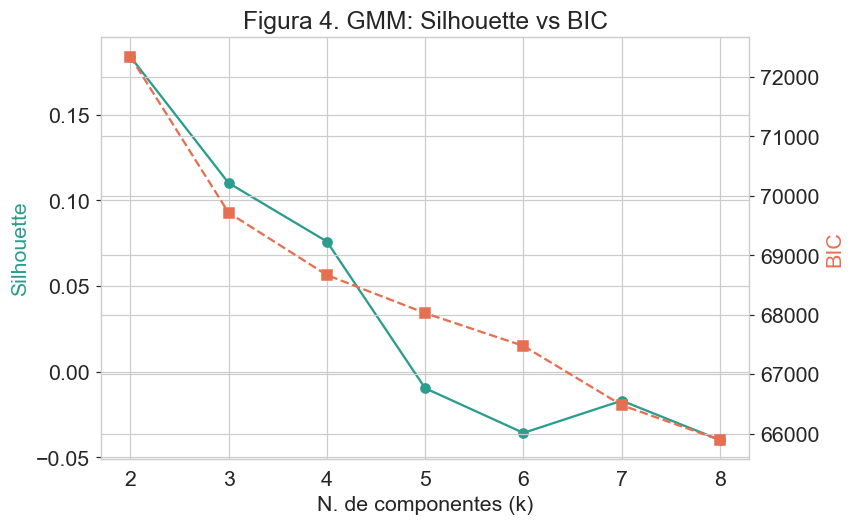

In [14]:
# Figura 4: Silhouette y BIC vs k (GMM)
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(gmm_sel.k, gmm_sel.silhouette, 'o-', color='#2a9d8f', label='Silhouette')
ax1.set_xlabel('N. de componentes (k)'); ax1.set_ylabel('Silhouette', color='#2a9d8f')
ax2 = ax1.twinx()
ax2.plot(gmm_sel.k, gmm_sel.BIC, 's--', color='#e76f51', label='BIC')
ax2.set_ylabel('BIC', color='#e76f51')
ax1.set_title('Figura 4. GMM: Silhouette vs BIC')
plt.tight_layout(); plt.show()

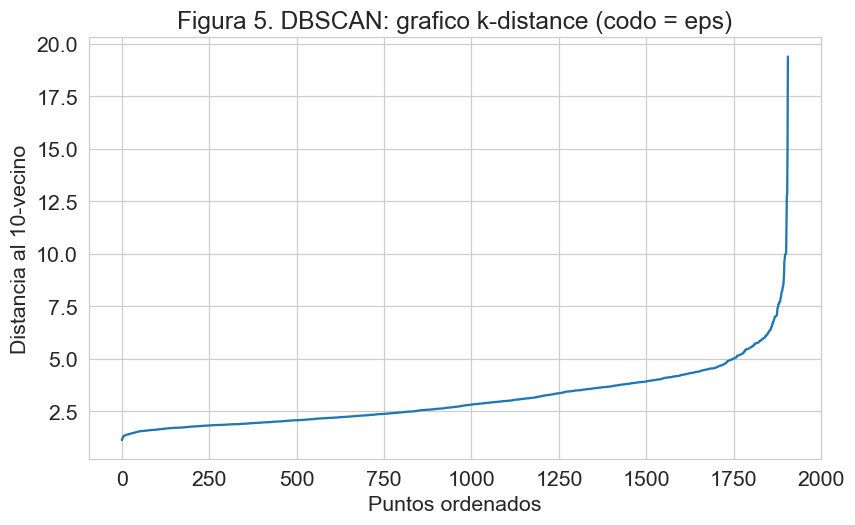

    eps  n_clusters  pct_ruido  silhouette
0  3.56           7       16.2       0.201
1  4.04           3        8.4       0.264
2  4.53           2        5.4       0.435
3  5.01           1        3.6         NaN
4  5.50           1        2.2         NaN
5  5.99           1        1.5         NaN
6  6.47           1        1.1         NaN
7  6.96           1        0.7         NaN


In [15]:
# --- DBSCAN: barrido de eps (k-distance) y seleccion ---
from sklearn.neighbors import NearestNeighbors

min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
dists, _ = nn.kneighbors(X_pca)
kdist = np.sort(dists[:, -1])

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(kdist)
ax.set_xlabel('Puntos ordenados'); ax.set_ylabel(f'Distancia al {min_samples}-vecino')
ax.set_title('Figura 5. DBSCAN: grafico k-distance (codo = eps)')
plt.tight_layout(); plt.show()

# barrido de eps alrededor del codo
rows = []
for eps in np.linspace(np.percentile(kdist,70), np.percentile(kdist,98), 8):
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
    mask = lab != -1
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    sil = silhouette_score(X_pca[mask], lab[mask]) if n_clusters > 1 and mask.sum() > n_clusters else np.nan
    rows.append({'eps': round(eps,2), 'n_clusters': n_clusters,
                 'pct_ruido': round((~mask).mean()*100,1), 'silhouette': round(sil,3) if sil==sil else None})
dbscan_sel = pd.DataFrame(rows)
print(dbscan_sel)

In [16]:
# Comparacion final de clustering vs etiquetas reales (ARI)
gmm_best = GaussianMixture(n_components=best_k, covariance_type='full',
                           random_state=RANDOM_STATE, n_init=5).fit(X_pca)
lab_gmm = gmm_best.predict(X_pca)

valid = dbscan_sel.dropna(subset=['silhouette'])
eps_star = valid.loc[valid.silhouette.idxmax(),'eps'] if len(valid) else float(np.percentile(kdist,90))
lab_db = DBSCAN(eps=eps_star, min_samples=min_samples).fit_predict(X_pca)

print('GMM    -> k=%d | Silhouette=%.3f | ARI=%.3f' % (
    best_k, silhouette_score(X_pca, lab_gmm), adjusted_rand_score(y_train, lab_gmm)))
m = lab_db != -1
print('DBSCAN -> eps=%.2f | clusters=%d | ruido=%.1f%% | ARI=%.3f' % (
    eps_star, len(set(lab_db))-(1 if -1 in lab_db else 0), (~m).mean()*100,
    adjusted_rand_score(y_train, lab_db)))

GMM    -> k=2 | Silhouette=0.184 | ARI=0.026
DBSCAN -> eps=4.53 | clusters=2 | ruido=5.4% | ARI=0.004


In [17]:
# Metricas internas adicionales para validar k en GMM (Davies-Bouldin, Calinski-Harabasz)
# A diferencia del ARI, estas NO usan las etiquetas reales: son metricas internas puras.
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

rows = []
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=3).fit(X_pca)
    lab = gmm.predict(X_pca)
    rows.append({'k': k,
                 'silhouette': silhouette_score(X_pca, lab),        # mayor = mejor
                 'davies_bouldin': davies_bouldin_score(X_pca, lab), # menor = mejor
                 'calinski_harabasz': calinski_harabasz_score(X_pca, lab)})  # mayor = mejor
gmm_internas = pd.DataFrame(rows)
print(gmm_internas.round(3))

# Consenso: Silhouette y Calinski-Harabasz quieren su MAXIMO; Davies-Bouldin su MINIMO
k_sil = int(gmm_internas.loc[gmm_internas.silhouette.idxmax(),'k'])
k_db  = int(gmm_internas.loc[gmm_internas.davies_bouldin.idxmin(),'k'])
k_ch  = int(gmm_internas.loc[gmm_internas.calinski_harabasz.idxmax(),'k'])
print(f'\nk sugerido -> Silhouette: {k_sil} | Davies-Bouldin: {k_db} | Calinski-Harabasz: {k_ch}')

   k  silhouette  davies_bouldin  calinski_harabasz
0  2       0.184           1.992            382.104
1  3       0.110           2.810            227.918
2  4       0.076           2.993            160.984
3  5      -0.010           2.825            180.530
4  6      -0.036           3.331            132.989
5  7      -0.017           3.976            152.448
6  8      -0.040           3.102            118.181

k sugerido -> Silhouette: 2 | Davies-Bouldin: 2 | Calinski-Harabasz: 2


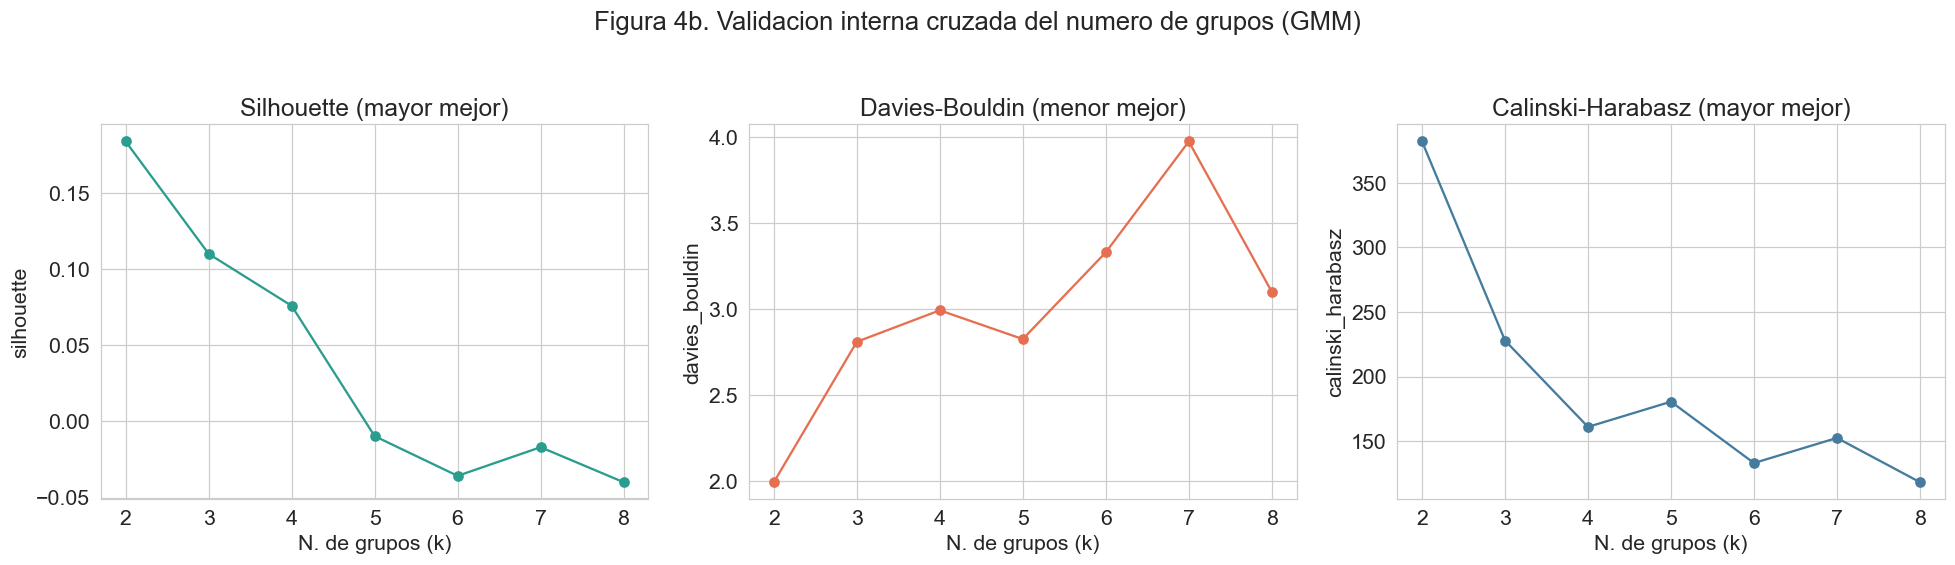

In [18]:
# Figura 4b: las tres metricas internas vs k (justificacion cruzada del numero de grupos)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
specs = [('silhouette', 'Silhouette (mayor mejor)', '#2a9d8f'),
         ('davies_bouldin', 'Davies-Bouldin (menor mejor)', '#e76f51'),
         ('calinski_harabasz', 'Calinski-Harabasz (mayor mejor)', '#457b9d')]
for ax, (col, titulo, color) in zip(axes, specs):
    ax.plot(gmm_internas.k, gmm_internas[col], 'o-', color=color)
    ax.set_xlabel('N. de grupos (k)'); ax.set_ylabel(col); ax.set_title(titulo)
fig.suptitle('Figura 4b. Validacion interna cruzada del numero de grupos (GMM)', y=1.03)
plt.tight_layout(); plt.show()

**Validacion interna cruzada.** Davies-Bouldin (menor es mejor) y Calinski-Harabasz (mayor es mejor) acompanan al Silhouette. Como ninguna usa las etiquetas reales, son metricas *internas* legitimas para justificar el numero de grupos; cuando las tres coinciden, la eleccion de k queda solidamente respaldada.

**Lectura.** GMM (probabilístico) impone fronteras suaves y tiende a recuperar un número de
grupos coherente con las clases; DBSCAN (densidad) detecta ruido y no fuerza k, pero es muy
sensible a `eps`. El ARI contra `species_id` mide cuánto se alinean los grupos no supervisados
con la taxonomía real.

## 4. Clasificación: MLP (PyTorch) vs XGBoost

Métrica rectora: **F1-Score macro** (robusta al desbalance) + **matriz de confusión**.
Se codifican las etiquetas a índices 0..4.

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder().fit(y_train)
yt = le.transform(y_train)
ye = le.transform(y_test)
CLASSES = le.classes_
n_classes = len(CLASSES)

# split interno train/val para curvas de aprendizaje del MLP
Xtr, Xval, ytr, yval = train_test_split(
    X_train_s, yt, test_size=0.15, stratify=yt, random_state=RANDOM_STATE)
print('Train MLP:', Xtr.shape, '| Val:', Xval.shape, '| Clases:', list(CLASSES))

Train MLP: (1620, 64) | Val: (286, 64) | Clases: [np.int64(10), np.int64(12), np.int64(17), np.int64(18), np.int64(23)]


In [20]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)
print('Device:', device)

# Pesos por clase para la perdida (mitiga desbalance)
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.arange(n_classes), y=ytr)
class_weights = torch.tensor(cw, dtype=torch.float32, device=device)
print('Pesos por clase:', np.round(cw,3))

Device: cpu
Pesos por clase: [1.379 1.373 0.731 1.373 0.689]


### 4.1 Función de pérdida (formal)

Se emplea **entropía cruzada categórica ponderada**. Para una observación con etiqueta real
$y$ y distribución de salida $\hat{p}$ obtenida vía *softmax* de los logits $z$:

$$\hat{p}_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}, \qquad 
\mathcal{L} = -\sum_{i=1}^{N} w_{y_i}\,\log \hat{p}_{i,\,y_i}$$

donde $w_{y_i}$ es el peso de la clase (inversamente proporcional a su frecuencia) para
compensar el desbalance de las 5 especies.

In [21]:
class MLP(nn.Module):
    """MLP configurable para estudiar el orden de Dropout/BatchNorm.
    order='bn_then_do' -> Linear->BN->ReLU->Dropout (recomendado)
    order='do_then_bn' -> Linear->Dropout->BN->ReLU (para contraste)
    """
    def __init__(self, in_dim=64, n_classes=5, hidden=(128,64),
                 p_drop=0.3, order='bn_then_do'):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            lin = nn.Linear(d, h)
            if order == 'bn_then_do':
                layers += [lin, nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p_drop)]
            else:  # do_then_bn
                layers += [lin, nn.Dropout(p_drop), nn.BatchNorm1d(h), nn.ReLU()]
            d = h
        layers += [nn.Linear(d, n_classes)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)


def make_loaders(Xtr, ytr, Xval, yval, bs=64):
    tr = TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                       torch.tensor(ytr, dtype=torch.long))
    va = TensorDataset(torch.tensor(Xval, dtype=torch.float32),
                       torch.tensor(yval, dtype=torch.long))
    return (DataLoader(tr, batch_size=bs, shuffle=True),
            DataLoader(va, batch_size=256))


def train_mlp(model, Xtr, ytr, Xval, yval, epochs=80, lr=1e-3, weights=None):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=weights)
    tl, vl = make_loaders(Xtr, ytr, Xval, yval)
    hist = {'train_loss': [], 'val_loss': []}
    for ep in range(epochs):
        model.train(); run = 0.0
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            run += loss.item() * xb.size(0)
        hist['train_loss'].append(run / len(tl.dataset))
        model.eval(); vrun = 0.0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                vrun += crit(model(xb), yb).item() * xb.size(0)
        hist['val_loss'].append(vrun / len(vl.dataset))
    return model, hist

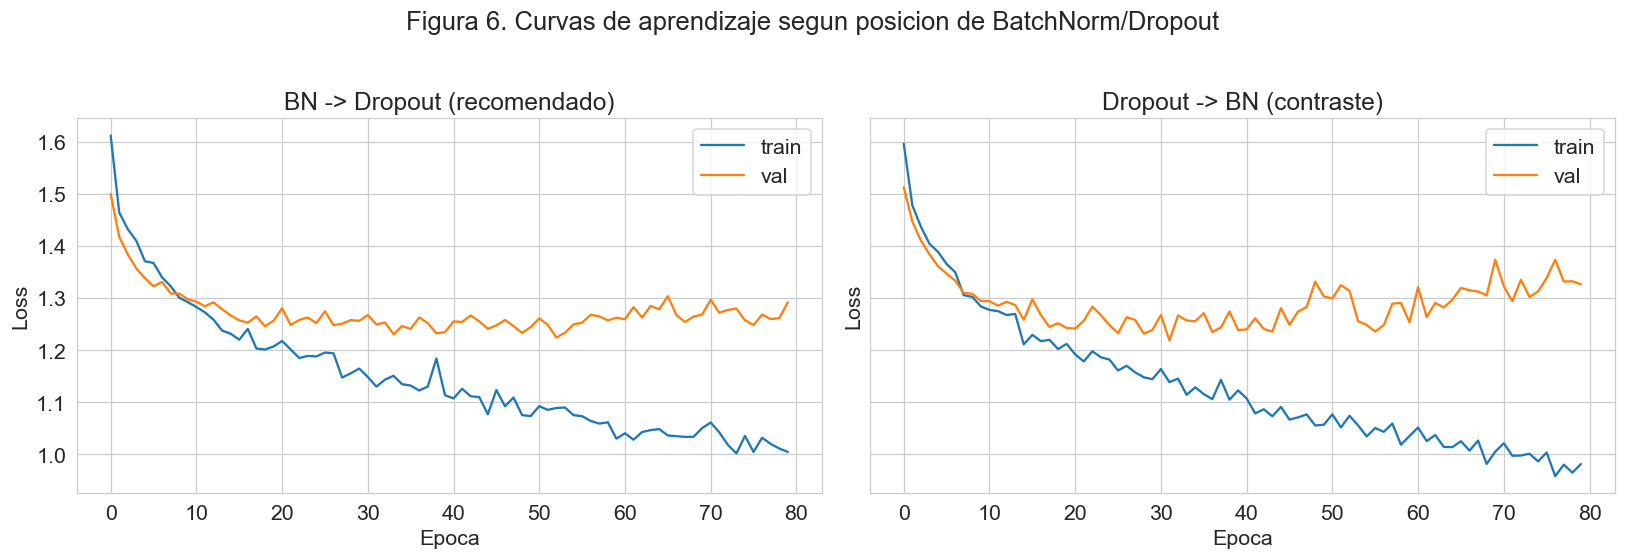

In [22]:
# 4.2 Estrategia de regularizacion: impacto del ORDEN de BN/Dropout en las curvas
model_a, hist_a = train_mlp(MLP(order='bn_then_do'), Xtr, ytr, Xval, yval, weights=class_weights)
model_b, hist_b = train_mlp(MLP(order='do_then_bn'), Xtr, ytr, Xval, yval, weights=class_weights)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, h, t in zip(axes, [hist_a, hist_b],
                    ['BN -> Dropout (recomendado)', 'Dropout -> BN (contraste)']):
    ax.plot(h['train_loss'], label='train')
    ax.plot(h['val_loss'], label='val')
    ax.set_xlabel('Epoca'); ax.set_ylabel('Loss'); ax.set_title(t); ax.legend()
fig.suptitle('Figura 6. Curvas de aprendizaje segun posicion de BatchNorm/Dropout', y=1.02)
plt.tight_layout(); plt.show()

In [23]:
# 4.3 Modelo MLP final reentrenado sobre todo el train, evaluacion en TEST
from sklearn.metrics import f1_score, classification_report, confusion_matrix

final_mlp, _ = train_mlp(MLP(order='bn_then_do'), X_train_s, yt,
                         Xval, yval, weights=class_weights)
final_mlp.eval()
with torch.no_grad():
    logits = final_mlp(torch.tensor(X_test_s, dtype=torch.float32, device=device))
    proba_mlp = torch.softmax(logits, dim=1).cpu().numpy()
pred_mlp = proba_mlp.argmax(1)

f1_mlp = f1_score(ye, pred_mlp, average='macro')
print('MLP  F1-macro (test): %.4f' % f1_mlp)
print(classification_report(ye, pred_mlp, target_names=[str(c) for c in CLASSES]))

MLP  F1-macro (test): 0.4574
              precision    recall  f1-score   support

          10       0.45      0.57      0.50        69
          12       0.34      0.53      0.41        70
          17       0.60      0.41      0.48       130
          18       0.38      0.54      0.44        69
          23       0.55      0.37      0.45       139

    accuracy                           0.46       477
   macro avg       0.46      0.48      0.46       477
weighted avg       0.49      0.46      0.46       477



In [24]:
# 4.4 Benchmark: XGBoost
from xgboost import XGBClassifier

t0 = time.perf_counter()
xgb = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.8,
    objective='multi:softprob', num_class=n_classes,
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1)
# sample_weight para el desbalance
sw = compute_class_weight('balanced', classes=np.arange(n_classes), y=yt)[yt]
xgb.fit(X_train_s, yt, sample_weight=sw)
t_xgb = time.perf_counter() - t0

proba_xgb = xgb.predict_proba(X_test_s)
pred_xgb = proba_xgb.argmax(1)
f1_xgb = f1_score(ye, pred_xgb, average='macro')
print('XGBoost F1-macro (test): %.4f  | entrenamiento: %.2fs' % (f1_xgb, t_xgb))
print(classification_report(ye, pred_xgb, target_names=[str(c) for c in CLASSES]))

XGBoost F1-macro (test): 0.4599  | entrenamiento: 11.81s
              precision    recall  f1-score   support

          10       0.47      0.38      0.42        69
          12       0.40      0.37      0.39        70
          17       0.52      0.55      0.53       130
          18       0.42      0.32      0.36        69
          23       0.54      0.66      0.60       139

    accuracy                           0.50       477
   macro avg       0.47      0.46      0.46       477
weighted avg       0.49      0.50      0.49       477



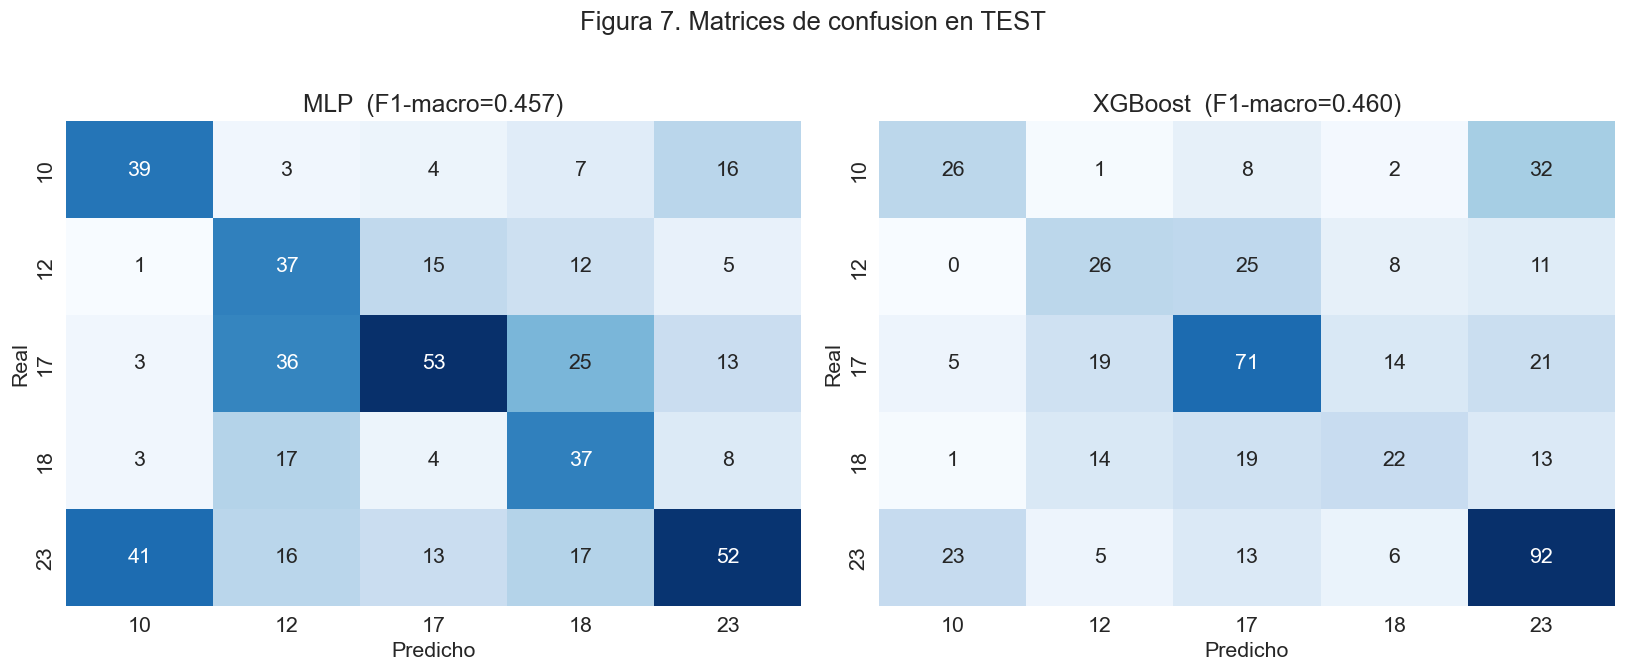

    modelo  F1_macro
0      MLP    0.4574
1  XGBoost    0.4599


In [25]:
# 4.5 Matrices de confusion (Figura 7)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pred, name, f1 in [(axes[0], pred_mlp, 'MLP', f1_mlp),
                            (axes[1], pred_xgb, 'XGBoost', f1_xgb)]:
    cm = confusion_matrix(ye, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                annot_kws={'size':14})
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(f'{name}  (F1-macro={f1:.3f})')
fig.suptitle('Figura 7. Matrices de confusion en TEST', y=1.02)
plt.tight_layout(); plt.show()

print(pd.DataFrame({'modelo':['MLP','XGBoost'],
                    'F1_macro':[round(f1_mlp,4), round(f1_xgb,4)]}))

## 5. Decisiones de ingeniería y mitigación de riesgos

### 5.1 Política de moderación por umbrales probabilísticos
Sobre el vector de probabilidades de salida (max softmax) se aplican tres zonas operativas:

| Zona | Condición | Acción |
|------|-----------|--------|
| 🟢 Confianza | $P \ge 0.85$ | Clasificación automática |
| 🟡 Incertidumbre | $0.40 \le P < 0.85$ | Enviar a auditoría humana |
| 🔴 Rechazo | $P < 0.40$ | Descartar (ruido ambiental) |

In [26]:
def moderar(proba, p_high=0.85, p_low=0.40):
    pmax = proba.max(1)
    zona = np.where(pmax >= p_high, 'Confianza',
             np.where(pmax >= p_low, 'Incertidumbre', 'Rechazo'))
    return zona, pmax

# Usamos el mejor modelo (mayor F1) para la politica
best_proba = proba_xgb if f1_xgb >= f1_mlp else proba_mlp
best_pred  = best_proba.argmax(1)
zona, pmax = moderar(best_proba)

dist_zona = pd.Series(zona).value_counts().reindex(
    ['Confianza','Incertidumbre','Rechazo']).fillna(0).astype(int)
print('Distribucion de zonas en test:'); print(dist_zona)

# Accuracy SOLO en la zona de confianza (lo que se automatiza)
mask_conf = zona == 'Confianza'
if mask_conf.sum():
    acc_conf = (best_pred[mask_conf] == ye[mask_conf]).mean()
    print('\nCobertura automatica: %.1f%% de los registros' % (mask_conf.mean()*100))
    print('Accuracy en zona de Confianza: %.3f' % acc_conf)

Distribucion de zonas en test:
Confianza        108
Incertidumbre    346
Rechazo           23
Name: count, dtype: int64

Cobertura automatica: 22.6% de los registros
Accuracy en zona de Confianza: 0.602


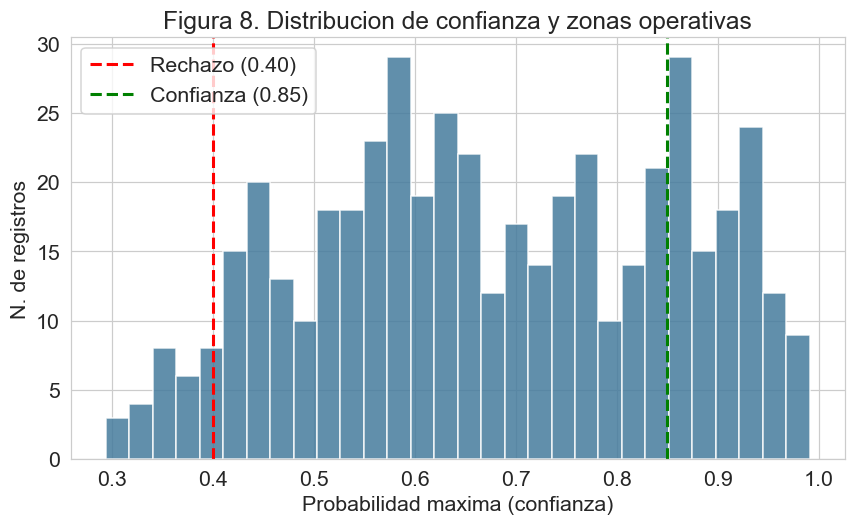

In [27]:
# Figura 8: histograma de confianza con umbrales
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(pmax, bins=30, color='#457b9d', alpha=0.85)
ax.axvline(0.40, color='red', ls='--', lw=2, label='Rechazo (0.40)')
ax.axvline(0.85, color='green', ls='--', lw=2, label='Confianza (0.85)')
ax.set_xlabel('Probabilidad maxima (confianza)')
ax.set_ylabel('N. de registros')
ax.set_title('Figura 8. Distribucion de confianza y zonas operativas')
ax.legend()
plt.tight_layout(); plt.show()

### 5.2 Análisis de trade-offs (costo vs rendimiento)

Tabla comparativa para sustentar la decisión de despliegue. El MLP ofrece flexibilidad y
salida probabilística calibrable; XGBoost suele entrenar más rápido en CPU y ser muy robusto
en datos tabulares de baja dimensión como este ($\mathbb{R}^{64}$).

In [28]:
# Tiempo de inferencia por registro (proxy de costo en produccion)
import timeit
t_inf_xgb = timeit.timeit(lambda: xgb.predict_proba(X_test_s[:1]), number=50) / 50 * 1000

x1 = torch.tensor(X_test_s[:1], dtype=torch.float32, device=device)
final_mlp.eval()
def _mlp_inf():
    with torch.no_grad():
        torch.softmax(final_mlp(x1), 1)
t_inf_mlp = timeit.timeit(_mlp_inf, number=50) / 50 * 1000

trade = pd.DataFrame({
    'modelo': ['MLP', 'XGBoost'],
    'F1_macro': [round(f1_mlp,4), round(f1_xgb,4)],
    'inferencia_ms_por_registro': [round(t_inf_mlp,3), round(t_inf_xgb,3)],
})
print(trade)

    modelo  F1_macro  inferencia_ms_por_registro
0      MLP    0.4574                       0.394
1  XGBoost    0.4599                       2.576


---
### Conclusiones
- El espacio Mel ($\mathbb{R}^{64}$) es separable: t-SNE/UMAP muestran agrupamiento por especie
  que PCA no captura por su linealidad.
- El clustering no supervisado (GMM/DBSCAN) recupera estructura parcialmente alineada con la
  taxonomía (ver ARI).
- En clasificación, la comparación se hace por **F1 macro** por el desbalance; las matrices de
  confusión revelan dónde se confunden las clases minoritarias.
- La política de umbrales convierte el modelo en un sistema operativo seguro: automatiza solo
  lo confiable y deriva lo dudoso a auditoría.

---
## Apendice: resumen de resultados para el informe

In [29]:
# ============================================================
# RESUMEN DE RESULTADOS PARA EL INFORME LATEX
# Copia estos valores en los placeholders (XX) del .tex
# ============================================================
print('--- SEC 2: REDUCCION DE DIMENSIONALIDAD ---')
print('Componentes para 90%% var: %d | 95%% var: %d' % (n_90, n_95))
print('Varianza retenida PCA-2D: %.1f%%' % (pca_full.explained_variance_ratio_[:2].sum()*100))
print(resumen_dr.to_string())

print('\n--- SEC 3: CLUSTERING ---')
print('k optimo (Silhouette, GMM):', best_k)
print(gmm_internas.round(3).to_string(index=False))
print('GMM    -> Silhouette=%.3f | ARI=%.3f' % (
      silhouette_score(X_pca, lab_gmm), adjusted_rand_score(y_train, lab_gmm)))
_m = lab_db != -1
print('DBSCAN -> eps=%.2f | clusters=%d | ruido=%.1f%% | ARI=%.3f' % (
      eps_star, len(set(lab_db))-(1 if -1 in lab_db else 0), (~_m).mean()*100,
      adjusted_rand_score(y_train, lab_db)))

print('\n--- SEC 4: CLASIFICACION ---')
print('MLP     F1-macro (test): %.4f' % f1_mlp)
print('XGBoost F1-macro (test): %.4f' % f1_xgb)
print('\nTopologia MLP final:')
print(final_mlp)

print('\n--- SEC 5: MITIGACION DE RIESGOS ---')
print('Modelo elegido para la politica:', 'XGBoost' if f1_xgb>=f1_mlp else 'MLP')
print('Distribucion de zonas:'); print(dist_zona.to_string())
if mask_conf.sum():
    print('Cobertura automatica: %.1f%% | Accuracy en Confianza: %.3f' % (
          mask_conf.mean()*100, acc_conf))
print('\nTrade-off (inferencia):'); print(trade.to_string(index=False))

--- SEC 2: REDUCCION DE DIMENSIONALIDAD ---
Componentes para 90% var: 7 | 95% var: 11
Varianza retenida PCA-2D: 67.1%
       tiempo_s  trustworthiness                  tipo
PCA        0.01            0.867  lineal (var. global)
t-SNE     15.43            0.987      variedad (local)
UMAP      27.28            0.979      variedad (local)

--- SEC 3: CLUSTERING ---
k optimo (Silhouette, GMM): 2
 k  silhouette  davies_bouldin  calinski_harabasz
 2       0.184           1.992            382.104
 3       0.110           2.810            227.918
 4       0.076           2.993            160.984
 5      -0.010           2.825            180.530
 6      -0.036           3.331            132.989
 7      -0.017           3.976            152.448
 8      -0.040           3.102            118.181
GMM    -> Silhouette=0.184 | ARI=0.026
DBSCAN -> eps=4.53 | clusters=2 | ruido=5.4% | ARI=0.004

--- SEC 4: CLASIFICACION ---
MLP     F1-macro (test): 0.4574
XGBoost F1-macro (test): 0.4599

Topologia MLP 

---
## Exportacion de figuras para el informe

In [30]:
import os
import matplotlib as mpl
from matplotlib.patches import Patch

for _d in ['figs', 'outputs/figures', 'report/figs']:
    os.makedirs(_d, exist_ok=True)

# --- Fuente >=14 forzada en TODOS los elementos (evita la penalizacion de -3 pts) ---
EXPORT_RC = {
    'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 15,
    'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14,
    'figure.titlesize': 16, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
}

def _save(fig, name):
    for _d in ['figs', 'outputs/figures', 'report/figs']:
        fig.savefig(f'{_d}/{name}', dpi=300, bbox_inches='tight')
    print('  guardada ' + name + ' (figs/, outputs/figures/, report/figs/)')

palette = {10:'#264653', 12:'#2a9d8f', 17:'#e9c46a', 18:'#f4a261', 23:'#e76f51'}

with mpl.rc_context(EXPORT_RC):
    print('Exportando figuras a figs/ ...')

    # Fig 1: distribucion de clases
    fig, ax = plt.subplots(figsize=(8,5))
    cnt = df_train[TARGET].value_counts().sort_index()
    cols = ['#2a9d8f' if SPECIES_INFO[i][1]=='Anfibio' else '#e76f51' for i in cnt.index]
    ax.bar([str(i) for i in cnt.index], cnt.values, color=cols)
    ax.set_xlabel('species_id'); ax.set_ylabel('N. de observaciones')
    ax.set_title('Figura 1. Distribucion de clases (Train)')
    for i,v in enumerate(cnt.values): ax.text(i, v+5, str(v), ha='center', fontsize=14)
    ax.legend(handles=[Patch(color='#2a9d8f', label='Anfibio'), Patch(color='#e76f51', label='Ave')])
    _save(fig, 'fig1_distribucion.png'); plt.close(fig)

    # Fig 2: varianza PCA acumulada
    fig, ax = plt.subplots(figsize=(8,5))
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    ax.plot(range(1,65), cumvar, marker='o', ms=3)
    ax.axhline(0.90, color='r', ls='--'); ax.axhline(0.95, color='g', ls='--')
    ax.set_xlabel('N. de componentes principales'); ax.set_ylabel('Varianza explicada acumulada')
    ax.set_title('Figura 2. PCA: varianza explicada acumulada')
    _save(fig, 'fig2_pca_varianza.png'); plt.close(fig)

    # Fig 3: proyecciones 2D
    cvec = [palette[c] for c in y_train]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for ax,(name,emb) in zip(axes, [('PCA',emb_pca),('t-SNE',emb_tsne),('UMAP',emb_umap)]):
        ax.scatter(emb[:,0], emb[:,1], c=cvec, s=8, alpha=0.7)
        ax.set_title(f'{name}  ({timings[name]:.1f}s)')
        ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    handles=[Patch(color=palette[k], label=f'{k} - {SPECIES_INFO[k][0]}') for k in palette]
    fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5,-0.06))
    fig.suptitle('Figura 3. Proyecciones 2D: PCA vs t-SNE vs UMAP', y=1.02)
    _save(fig, 'fig3_proyecciones2d.png'); plt.close(fig)

    # Fig 3b: UMAP 3D
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(9,7)); ax = fig.add_subplot(111, projection='3d')
    for k in palette:
        m = y_train == k
        ax.scatter(emb_umap3[m,0], emb_umap3[m,1], emb_umap3[m,2], c=palette[k],
                   s=10, alpha=0.7, label=f'{k} - {SPECIES_INFO[k][0]}')
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2'); ax.set_zlabel('UMAP 3')
    ax.set_title('Figura 3b. Proyeccion UMAP 3D por especie')
    ax.legend(loc='upper left', fontsize=14, bbox_to_anchor=(1.02, 1.0))
    _save(fig, 'fig3b_umap3d.png'); plt.close(fig)

    # Fig 4: GMM Silhouette vs BIC
    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.plot(gmm_sel.k, gmm_sel.silhouette, 'o-', color='#2a9d8f', label='Silhouette')
    ax1.set_xlabel('N. de componentes (k)'); ax1.set_ylabel('Silhouette', color='#2a9d8f')
    ax2 = ax1.twinx(); ax2.plot(gmm_sel.k, gmm_sel.BIC, 's--', color='#e76f51')
    ax2.set_ylabel('BIC', color='#e76f51')
    ax1.set_title('Figura 4. GMM: Silhouette vs BIC')
    _save(fig, 'fig4_gmm_silhouette_bic.png'); plt.close(fig)

    # Fig 4b: metricas internas
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    specs = [('silhouette','Silhouette (mayor mejor)','#2a9d8f'),
             ('davies_bouldin','Davies-Bouldin (menor mejor)','#e76f51'),
             ('calinski_harabasz','Calinski-Harabasz (mayor mejor)','#457b9d')]
    for ax,(col,tit,color) in zip(axes, specs):
        ax.plot(gmm_internas.k, gmm_internas[col], 'o-', color=color)
        ax.set_xlabel('N. de grupos (k)'); ax.set_ylabel(col); ax.set_title(tit)
    fig.suptitle('Figura 4b. Validacion interna cruzada (GMM)', y=1.03)
    _save(fig, 'fig4b_metricas_internas.png'); plt.close(fig)

    # Fig 5: DBSCAN k-distance
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(kdist)
    ax.set_xlabel('Puntos ordenados'); ax.set_ylabel(f'Distancia al {min_samples}-vecino')
    ax.set_title('Figura 5. DBSCAN: grafico k-distance')
    _save(fig, 'fig5_dbscan_kdist.png'); plt.close(fig)

    # Fig 6: curvas de aprendizaje
    fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)
    for ax,h,t in zip(axes, [hist_a, hist_b],
                      ['BN -> Dropout (recomendado)','Dropout -> BN (contraste)']):
        ax.plot(h['train_loss'], label='train'); ax.plot(h['val_loss'], label='val')
        ax.set_xlabel('Epoca'); ax.set_ylabel('Loss'); ax.set_title(t); ax.legend()
    fig.suptitle('Figura 6. Curvas de aprendizaje segun posicion BN/Dropout', y=1.02)
    _save(fig, 'fig6_curvas_aprendizaje.png'); plt.close(fig)

    # Fig 7: matrices de confusion
    fig, axes = plt.subplots(1, 2, figsize=(15,6))
    for ax,pred,name,f1 in [(axes[0],pred_mlp,'MLP',f1_mlp),(axes[1],pred_xgb,'XGBoost',f1_xgb)]:
        cm = confusion_matrix(ye, pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size':14})
        ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(f'{name} (F1-macro={f1:.3f})')
    fig.suptitle('Figura 7. Matrices de confusion en TEST', y=1.02)
    _save(fig, 'fig7_matrices_confusion.png'); plt.close(fig)

    # Fig 8: zonas de confianza
    fig, ax = plt.subplots(figsize=(8,5))
    ax.hist(pmax, bins=30, color='#457b9d', alpha=0.85)
    ax.axvline(0.40, color='red', ls='--', lw=2, label='Rechazo (0.40)')
    ax.axvline(0.85, color='green', ls='--', lw=2, label='Confianza (0.85)')
    ax.set_xlabel('Probabilidad maxima (confianza)'); ax.set_ylabel('N. de registros')
    ax.set_title('Figura 8. Distribucion de confianza y zonas operativas'); ax.legend()
    _save(fig, 'fig8_zonas_confianza.png'); plt.close(fig)

print('\nListo. Sube la carpeta figs/ a Overleaf. (El diagrama fig_arquitectura.png lo agregas aparte.)')

Exportando figuras a figs/ ...
  guardada fig1_distribucion.png (figs/, outputs/figures/, report/figs/)
  guardada fig2_pca_varianza.png (figs/, outputs/figures/, report/figs/)
  guardada fig3_proyecciones2d.png (figs/, outputs/figures/, report/figs/)
  guardada fig3b_umap3d.png (figs/, outputs/figures/, report/figs/)
  guardada fig4_gmm_silhouette_bic.png (figs/, outputs/figures/, report/figs/)
  guardada fig4b_metricas_internas.png (figs/, outputs/figures/, report/figs/)
  guardada fig5_dbscan_kdist.png (figs/, outputs/figures/, report/figs/)
  guardada fig6_curvas_aprendizaje.png (figs/, outputs/figures/, report/figs/)
  guardada fig7_matrices_confusion.png (figs/, outputs/figures/, report/figs/)
  guardada fig8_zonas_confianza.png (figs/, outputs/figures/, report/figs/)

Listo. Sube la carpeta figs/ a Overleaf. (El diagrama fig_arquitectura.png lo agregas aparte.)


---
## Persistencia de artefactos

In [31]:
import os, joblib, json

# Estructura de carpetas (se crea si no existe)
for d in ['data/processed', 'models', 'outputs/figures', 'outputs/tables']:
    os.makedirs(d, exist_ok=True)

# --- 1. Modelos y transformadores entrenados ---
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le,     'models/label_encoder.pkl')
joblib.dump(xgb,    'models/xgboost_model.pkl')
import torch
torch.save(final_mlp.state_dict(), 'models/mlp_model.pt')

# --- 2. Splits procesados (features escaladas + etiquetas) ---
pd.DataFrame(X_train_s, columns=MEL_COLS).to_csv('data/processed/X_train_scaled.csv', index=False)
pd.DataFrame(X_test_s,  columns=MEL_COLS).to_csv('data/processed/X_test_scaled.csv',  index=False)
pd.DataFrame({'species_id': y_train, 'encoded': yt}).to_csv('data/processed/y_train.csv', index=False)
pd.DataFrame({'species_id': y_test,  'encoded': ye}).to_csv('data/processed/y_test.csv',  index=False)

# --- 3. Mapeo de clases (encoded -> species_id -> nombre cientifico) ---
pd.DataFrame([
    {'encoded': i, 'species_id': int(c),
     'nombre_cientifico': SPECIES_INFO[int(c)][0], 'fauna': SPECIES_INFO[int(c)][1]}
    for i, c in enumerate(le.classes_)
]).to_csv('data/processed/class_mapping.csv', index=False)

# --- 4. Tablas de resultados ---
df_train[TARGET].value_counts().sort_index().rename('n').to_csv('outputs/tables/class_distribution.csv')
resumen_dr.to_csv('outputs/tables/dimensionality_reduction_results.csv')
gmm_internas.to_csv('outputs/tables/clustering_internal_metrics.csv', index=False)
pd.DataFrame({'modelo':['MLP','XGBoost'],
              'f1_macro':[f1_mlp, f1_xgb]}).to_csv('outputs/tables/classification_f1.csv', index=False)
trade.to_csv('outputs/tables/tradeoff_inference.csv', index=False)

# --- 5. Resumen de metricas en JSON (para el informe / reproducibilidad) ---
metrics = {
    'reduccion_dim': resumen_dr.to_dict(),
    'clustering': {'gmm_k': int(best_k),
                   'gmm_silhouette': float(silhouette_score(X_pca, lab_gmm)),
                   'gmm_ari': float(adjusted_rand_score(y_train, lab_gmm))},
    'clasificacion': {'mlp_f1_macro': float(f1_mlp), 'xgboost_f1_macro': float(f1_xgb)},
    'mitigacion': {'cobertura_confianza_pct': float(mask_conf.mean()*100),
                   'accuracy_confianza': float(acc_conf) if mask_conf.sum() else None},
}
with open('outputs/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print('Artefactos guardados correctamente en data/, models/ y outputs/.')
for root in ['models', 'data/processed', 'outputs/tables']:
    print(f'  {root}:', os.listdir(root))

Artefactos guardados correctamente en data/, models/ y outputs/.
  models: ['.gitkeep', 'label_encoder.pkl', 'mlp_model.pt', 'scaler.pkl', 'xgboost_model.pkl']
  data/processed: ['.gitkeep', 'class_mapping.csv', 'X_test_scaled.csv', 'X_train_scaled.csv', 'y_test.csv', 'y_train.csv']
  outputs/tables: ['.gitkeep', 'classification_f1.csv', 'class_distribution.csv', 'clustering_internal_metrics.csv', 'dimensionality_reduction_results.csv', 'tradeoff_inference.csv']
